# UAVDT BEV Project — Notebook 01: Local dataset access and workspace

This notebook prepares a local workspace for the UAVDT → BEV reconstruction pipeline.

It does **not** perform BEV reconstruction yet. It only:
1. checks whether `dataset-tools` can be used in the current Python environment,
2. provides a safe optional download route,
3. discovers an existing UAVDT/UAV-benchmark-M folder locally,
4. creates image/sequence indexes,
5. creates a small sample folder for later notebooks.

Recommended first path: if you already have `UAV_benchmark_M` locally, skip the large download and use the discovery/indexing cells.


In [1]:
#@title 1. Runtime info

import sys
import os
from pathlib import Path

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", os.getcwd())


Python executable: /Users/vash/Dev/ResearchLab/Work/Drone3D/.venv/bin/python
Python version: 3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
Current working directory: /Users/vash/Dev/ResearchLab/Work/Drone3D


In [2]:
#@title 2. Set local project paths

from pathlib import Path
from notebook_local import resolve_project_dir, find_uavdt_root, print_local_setup

PROJECT_ROOT = resolve_project_dir()
RAW_ROOT = PROJECT_ROOT / "raw"
WORK_ROOT = PROJECT_ROOT / "work"
INDEX_ROOT = PROJECT_ROOT / "indexes"
DATASET_ROOT = find_uavdt_root(PROJECT_ROOT)

for path in [PROJECT_ROOT, RAW_ROOT, WORK_ROOT, INDEX_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print_local_setup(PROJECT_ROOT, DATASET_ROOT)
print("Raw root:", RAW_ROOT)
print("Work root:", WORK_ROOT)
print("Index root:", INDEX_ROOT)


PROJECT_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project
DATASET_DIR: /Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-benchmark-M
Set DRONE3D_PROJECT_DIR and UAVDT_DATASET_DIR to override these defaults.
Raw root: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/raw
Work root: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work
Index root: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/indexes


In [3]:
#@title 3. Optional: probe dataset-tools without breaking the runtime

# The normal command from Dataset Ninja is:
#   pip install --upgrade dataset-tools
#
# In some current Colab runtimes, dependency resolution can try to build an old pandas
# from source and fail. This cell avoids that by installing only the dataset-tools wheel
# and then checking whether importing it works. This is a probe, not a required step.

INSTALL_DATASET_TOOLS_PROBE = True #@param {type:"boolean"}

import sys
import subprocess
import importlib
import inspect

dtools = None

if INSTALL_DATASET_TOOLS_PROBE:
    print("Installing dataset-tools wheel only, without dependencies.")
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-deps",
        "--only-binary=:all:",
        "dataset-tools==0.1.9",
    ]
    result = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print("pip return code:", result.returncode)
    if result.stdout.strip():
        print(result.stdout[-3000:])

try:
    dtools = importlib.import_module("dataset_tools")
    print("dataset_tools import: OK")
    print("dataset_tools location:", getattr(dtools, "__file__", "unknown"))

    if hasattr(dtools, "download"):
        print("dtools.download exists: yes")
        try:
            print("dtools.download signature:", inspect.signature(dtools.download))
        except Exception as exc:
            print("Could not inspect dtools.download signature:", repr(exc))
    else:
        print("dtools.download exists: no")
except Exception as exc:
    print("dataset_tools import: FAILED")
    print("Reason:", repr(exc))
    print("This is not fatal. Continue with the existing Drive folder or direct-download cells.")


Installing dataset-tools wheel only, without dependencies.
pip return code: 0

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /Users/vash/Dev/ResearchLab/Work/Drone3D/.venv/bin/python -m pip install --upgrade pip

dataset_tools import: FAILED
Reason: DistributionNotFound(Requirement.parse('imagesize==1.4.1'), {'dataset-tools'})
This is not fatal. Continue with the existing Drive folder or direct-download cells.


/Users/vash/Dev/ResearchLab/Work/Drone3D/.venv/lib/python3.13/site-packages/dataset_tools/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # isort: skip


In [4]:
#@title 4. Optional: try dataset-tools download locally

# Leave this false unless the previous cell imported dataset_tools successfully.
# Full Dataset Ninja UAVDT is large, so only run this when you really want the download.

RUN_DATASET_TOOLS_DOWNLOAD = False #@param {type:"boolean"}
DATASET_TOOLS_DST = str(RAW_ROOT / "dataset_ninja") #@param {type:"string"}

if RUN_DATASET_TOOLS_DOWNLOAD:
    if dtools is None:
        raise RuntimeError("dataset_tools is not imported. Run the probe cell first and check errors.")

    dst_dir = Path(DATASET_TOOLS_DST).expanduser()
    dst_dir.mkdir(parents=True, exist_ok=True)

    print("Downloading UAVDT with dataset_tools to:", dst_dir)
    dtools.download(dataset="UAVDT", dst_dir=str(dst_dir))
    print("dataset_tools download finished.")
else:
    print("Skipped dataset_tools download.")
    print("DATASET_TOOLS_DST:", DATASET_TOOLS_DST)


Skipped dataset_tools download.
DATASET_TOOLS_DST: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/raw/dataset_ninja


In [5]:
#@title 5. Optional direct download of UAVDT-Benchmark-M zip from the published Google Drive link

# Dataset Ninja's GitHub download page also links the original UAVDT-Benchmark-M zip.
# This cell uses gdown with the known Google Drive file id.
#
# Keep this false if you already have a local UAV_benchmark_M directory.

RUN_DIRECT_GDRIVE_DOWNLOAD = False #@param {type:"boolean"}
UNZIP_AFTER_DOWNLOAD = False #@param {type:"boolean"}

UAV_BENCHMARK_M_FILE_ID = "1m8KA6oPIRK_Iwt9TYFquC87vBc_8wRVc"
ZIP_PATH = RAW_ROOT / "UAV-benchmark-M.zip"
EXTRACT_DIR = RAW_ROOT / "UAV-benchmark-M"

if RUN_DIRECT_GDRIVE_DOWNLOAD:
    import subprocess
    import sys

    print("Installing gdown.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=False)

    url = "https://drive.google.com/uc?id=" + UAV_BENCHMARK_M_FILE_ID
    print("Downloading:", url)
    print("Output zip:", ZIP_PATH)

    cmd = ["gdown", "--fuzzy", url, "-O", str(ZIP_PATH)]
    result = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print("gdown return code:", result.returncode)
    print(result.stdout[-3000:])

    if result.returncode != 0:
        raise RuntimeError("gdown download failed. You can still upload/copy the dataset manually to Drive.")

    if UNZIP_AFTER_DOWNLOAD:
        print("Unzipping to:", EXTRACT_DIR)
        EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        unzip_cmd = ["unzip", "-q", str(ZIP_PATH), "-d", str(EXTRACT_DIR)]
        unzip_result = subprocess.run(unzip_cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        print("unzip return code:", unzip_result.returncode)
        if unzip_result.stdout.strip():
            print(unzip_result.stdout[-3000:])
else:
    print("Skipped direct Google Drive download.")
    print("ZIP_PATH:", ZIP_PATH)
    print("EXTRACT_DIR:", EXTRACT_DIR)


Skipped direct Google Drive download.
ZIP_PATH: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/raw/UAV-benchmark-M.zip
EXTRACT_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/raw/UAV-benchmark-M


In [6]:
#@title 6. Discover UAVDT / UAV-benchmark-M images locally
from pathlib import Path
import json
import csv
from collections import defaultdict
from notebook_local import find_uavdt_root

DATASET_ROOT = find_uavdt_root(PROJECT_ROOT)
CANDIDATE_ROOTS = []
if DATASET_ROOT is not None:
    CANDIDATE_ROOTS.append(DATASET_ROOT)
CANDIDATE_ROOTS += [
    RAW_ROOT / 'UAV_benchmark_M',
    RAW_ROOT / 'UAV-benchmark-M',
    PROJECT_ROOT.parent / 'UAV_benchmark_M',
    PROJECT_ROOT.parent / 'UAV-benchmark-M',
]

seen = set()
existing_roots = []
for path in CANDIDATE_ROOTS:
    resolved = Path(path).expanduser()
    key = str(resolved)
    if key in seen:
        continue
    seen.add(key)
    if resolved.exists():
        existing_roots.append(resolved)

if not existing_roots:
    raise FileNotFoundError(
        'No UAVDT dataset root found. Set UAVDT_DATASET_DIR or copy UAV_benchmark_M under local_uav_bev_project/raw.'
    )

print('Dataset roots found:')
for path in existing_roots:
    print(' ', path)

rows = []
sequence_counts = defaultdict(int)
for dataset_root in existing_roots:
    for seq_dir in sorted([p for p in dataset_root.iterdir() if p.is_dir()]):
        image_files = sorted(
            [p for p in seq_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
        )
        if not image_files:
            continue
        sequence_counts[seq_dir.name] += len(image_files)
        for img_path in image_files:
            rows.append({
                'dataset_root': str(dataset_root),
                'sequence_name': seq_dir.name,
                'image_name': img_path.name,
                'image_path': str(img_path),
            })

manifest_path = INDEX_ROOT / 'uavdt_image_manifest.csv'
with open(manifest_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['dataset_root', 'sequence_name', 'image_name', 'image_path'])
    writer.writeheader()
    writer.writerows(rows)

counts_path = INDEX_ROOT / 'uavdt_sequence_counts.json'
with open(counts_path, 'w') as f:
    json.dump(dict(sorted(sequence_counts.items())), f, indent=2)

print('Saved manifest:', manifest_path)
print('Saved counts JSON:', counts_path)
print('Sequences discovered:', len(sequence_counts))
print('Images indexed:', len(rows))


Dataset roots found:
  /Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-benchmark-M
Saved manifest: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/indexes/uavdt_image_manifest.csv
Saved counts JSON: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/indexes/uavdt_sequence_counts.json
Sequences discovered: 50
Images indexed: 40735


In [7]:
#@title 7. Create a small working sample sequence for later notebooks

from pathlib import Path
import shutil
import json

image_exts = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

SEQUENCE_NAME = "M1401" #@param {type:"string"}
START_FRAME = 0 #@param {type:"integer"}
MAX_SOURCE_FRAMES = 200 #@param {type:"integer"}
FRAME_STEP = 5 #@param {type:"integer"}

if DATASET_ROOT is None:
    raise RuntimeError("DATASET_ROOT is not set. Run dataset discovery after placing data in Drive.")

candidate_sequence_dirs = [
    DATASET_ROOT / SEQUENCE_NAME,
    DATASET_ROOT / SEQUENCE_NAME / "img1",
]

sequence_dir = None
for candidate in candidate_sequence_dirs:
    if candidate.exists():
        sequence_dir = candidate
        break

if sequence_dir is None:
    matches = [p for p in DATASET_ROOT.rglob(SEQUENCE_NAME) if p.is_dir()]
    if matches:
        sequence_dir = matches[0]

if sequence_dir is None:
    raise RuntimeError("Could not find requested sequence: " + SEQUENCE_NAME)

all_images = sorted([p for p in sequence_dir.iterdir() if p.is_file() and p.suffix in image_exts])
print("Sequence directory:", sequence_dir)
print("Images in sequence:", len(all_images))

selected = all_images[START_FRAME:START_FRAME + MAX_SOURCE_FRAMES:FRAME_STEP]
print("Selected images:", len(selected))
if selected:
    print("First selected:", selected[0])
    print("Last selected:", selected[-1])

sample_dir = WORK_ROOT / (SEQUENCE_NAME + "_sample")
sample_images_dir = sample_dir / "images"

if sample_dir.exists():
    shutil.rmtree(sample_dir)

sample_images_dir.mkdir(parents=True, exist_ok=True)

sample_records = []
for i, src in enumerate(selected):
    dst = sample_images_dir / ("frame_" + str(i).zfill(5) + src.suffix.lower())
    shutil.copy2(src, dst)
    sample_records.append({
        "sample_index": i,
        "source_path": str(src),
        "sample_path": str(dst),
    })

sample_manifest = sample_dir / "sample_manifest.json"
with sample_manifest.open("w") as f:
    json.dump(sample_records, f, indent=2)

print("Sample folder:", sample_dir)
print("Sample image folder:", sample_images_dir)
print("Sample manifest:", sample_manifest)


Sequence directory: /Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-benchmark-M/M1401
Images in sequence: 1050
Selected images: 40
First selected: /Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-benchmark-M/M1401/img000001.jpg
Last selected: /Users/vash/Dev/ResearchLab/DataSets/UAV/UAV-benchmark-M/M1401/img000196.jpg
Sample folder: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample
Sample image folder: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample/images
Sample manifest: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample/sample_manifest.json


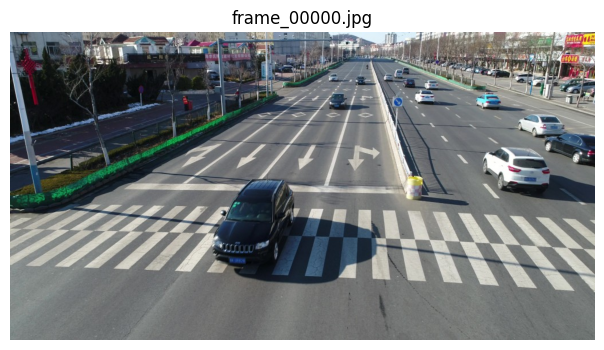

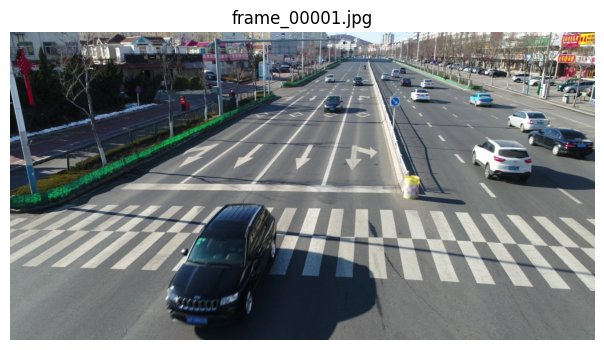

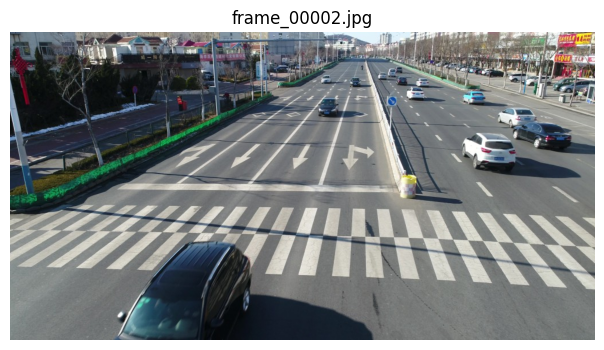

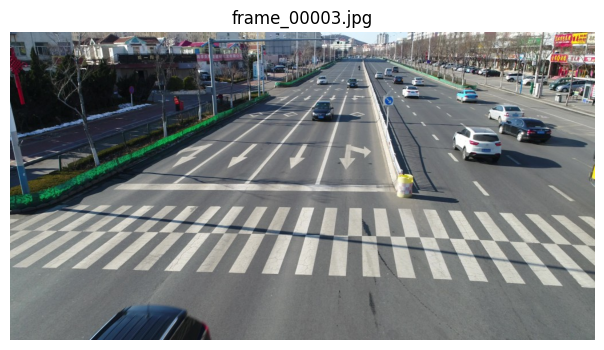

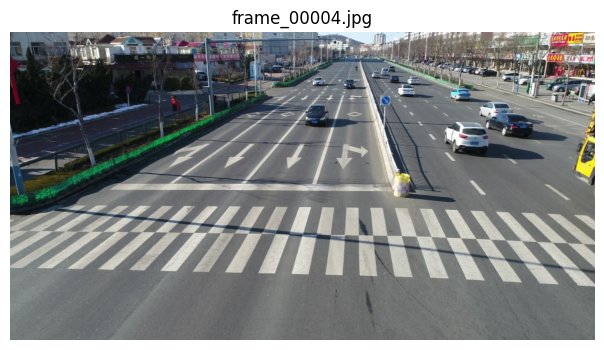

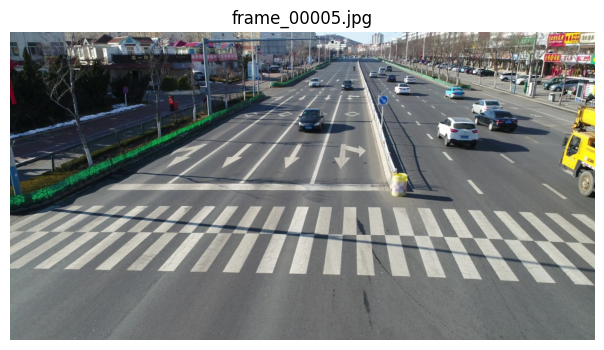

In [8]:
#@title 8. Preview sampled frames

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

preview_paths = sorted((WORK_ROOT / (SEQUENCE_NAME + "_sample") / "images").glob("*"))[:6]

if not preview_paths:
    print("No preview images found.")
else:
    for path in preview_paths:
        img = Image.open(path)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.title(path.name)
        plt.axis("off")
        plt.show()


## Output of this notebook

The important files for the next notebooks are:

```text
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/indexes/uavdt_image_manifest.csv
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/indexes/uavdt_sequence_counts.json
/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/M1401_sample/images/
```

Notebook 02 can use the sample images to estimate an automatic BEV homography and create a road-plane preview.
